# Adaptive Agent Analysis

Comprehensive analysis of the Neural LSTM-based Adaptive Agent performance:
- Inference time and computational efficiency
- Win rates against all opponents (with confidence intervals)
- Adversary identification speed and accuracy
- Performance breakdown by player position and opponent type

## 1. Import Required Libraries

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Tuple
from scipy import stats
import time

# Setup paths
sys.path.insert(0, str(Path().cwd().parent))

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Agent and Setup Game Environment

In [2]:
import importlib
import sys

# Reload modules to pick up code changes
modules_to_reload = [
    'liars_dice.agents.adapter_agent.adaptive_training',
    'liars_dice.agents.adapter_agent',
    'liars_dice.agents.adapter_agent.action_tracker',
    'liars_dice.agents.adaptive_agent',
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from liars_dice.core.config import GameConfig
from liars_dice.core.engine import GameEngine
from liars_dice.agents.adaptive_agent import AdaptiveAgent
from liars_dice.agents.ppo_agent import PPOAgent
from liars_dice.agents import AGENT_MAP
from liars_dice.agents.adapter_agent.config import PATH_CONFIG
from liars_dice.agents.adapter_agent.action_tracker import ActionTrackerWrapper

print("="*60)
print("AVAILABLE AGENTS IN AGENT_MAP")
print("="*60)
print(f"Total agents in AGENT_MAP: {len(AGENT_MAP)}")
print(f"Agent keys: {sorted(AGENT_MAP.keys())}\n")

# Build opponent classes (match train_adaptive_agent.py logic)
opponent_classes = {}
for agent_name, agent_cls in AGENT_MAP.items():
    if agent_name not in ["rl_ppo", "adaptive"]:  # Exclude base RL and adaptive
        try:
            _ = agent_cls()
            opponent_classes[agent_cls.__name__] = agent_cls
        except Exception:
            pass

# Add the frozen generalist PPO as an opponent
class GeneralistPPOAgent(PPOAgent):
    """Frozen generalist PPO model as a trainable opponent."""
    def __init__(self):
        super().__init__(model_path=PATH_CONFIG["generalist_model"], stochastic=False)

opponent_classes["GeneralistPPO"] = GeneralistPPOAgent

print("="*60)
print("OPPONENT CLASSES FOR ANALYSIS")
print("="*60)
print(f"Total opponent classes: {len(opponent_classes)}")
print(f"Opponents: {sorted(opponent_classes.keys())}\n")

# Verify all trainable agents are included (compare by class name)
available_class_names = {cls.__name__ for key, cls in AGENT_MAP.items() if key not in ["rl_ppo", "adaptive"]}
missing = available_class_names - set(opponent_classes.keys())
if missing:
    print(f"⚠️  Warning: These agent classes are not in opponent_classes: {sorted(missing)}")
else:
    print("✓ All available agents are included in opponent_classes")

# Initialize adaptive agent
try:
    adaptive_agent = AdaptiveAgent(device="cpu")
    print(f"\n✓ Adaptive Agent loaded successfully")
except Exception as e:
    print(f"Error loading Adaptive Agent: {e}")

AVAILABLE AGENTS IN AGENT_MAP
Total agents in AGENT_MAP: 29
Agent keys: ['adaptive', 'aggressive', 'alternator', 'bayesian', 'bluffing', 'chaotic', 'chaotic_safe', 'chaotic_unsafe', 'conservative', 'cycleface', 'maxcount', 'maxraise', 'minraise', 'mirror', 'nash_cfr', 'onesarewild', 'parity', 'probability_maxraise', 'probability_minraise', 'random', 'random_aggressive', 'random_cautious', 'random_facefixed', 'random_facerandom', 'randomface', 'randomthreshold', 'rl_ppo', 'safeface', 'thresholdliar']

OPPONENT CLASSES FOR ANALYSIS
Total opponent classes: 28
Opponents: ['AggressiveAgent', 'AggressiveRandomAgent', 'AlternatorAgent', 'BayesianAgent', 'BluffingAgent', 'CautiousRandomAgent', 'ChaoticAgent', 'ChaoticSafeAgent', 'ChaoticUnsafeAgent', 'ConservativeAgent', 'CycleFaceAgent', 'FaceFixedRandomAgent', 'FaceRandomRandomAgent', 'GeneralistPPO', 'MaxCountBidAgent', 'MaxRaiseAgent', 'MinRaiseAgent', 'MirrorAgent', 'NashCFRAgent', 'OnesAreWildAgent', 'ParityAgent', 'ProbabilityMaxRaiseAg

## 3. Game Metrics Collection Functions

In [3]:
class AdaptiveAgentMetrics:
    """Collects metrics during adaptive agent gameplay."""
    
    def __init__(self):
        self.inference_times = []  # Time per action selection
        self.steps_to_identification = None  # When was opponent identified
        self.predicted_opponent = None  # Predicted opponent (highest confidence)
        self.actual_opponent = None  # Ground truth opponent
        self.identification_correct = None  # Was prediction correct
        self.belief_trajectory = []  # Belief distribution over time
        self.won = None  # Did adaptive agent win
        self.was_player_0 = None  # Was adaptive agent player 0

def play_game_with_metrics(
    adaptive_agent: AdaptiveAgent,
    opponent_cls,
    opponent_name: str,
    game_config: GameConfig,
    adaptive_is_player_0: bool = True
) -> Tuple[AdaptiveAgentMetrics, bool]:
    """
    Play a game and collect metrics from the adaptive agent.
    IMPORTANT: Uses ActionTrackerWrapper to properly capture opponent actions for belief updating.
    
    Returns:
        metrics: AdaptiveAgentMetrics object
        adaptive_won: Whether adaptive agent won
    """    
    metrics = AdaptiveAgentMetrics()
    metrics.actual_opponent = opponent_name
    metrics.was_player_0 = adaptive_is_player_0
    
    # Setup agents
    opponent = opponent_cls()
    adaptive_agent.reset()
    
    # Wrap opponent to track its actions
    wrapped_opponent = ActionTrackerWrapper(opponent, adaptive_agent=adaptive_agent)
    
    if adaptive_is_player_0:
        agents = [adaptive_agent, wrapped_opponent]
        adaptive_player = 0
    else:
        agents = [wrapped_opponent, adaptive_agent]
        adaptive_player = 1
    
    # Play match with dice elimination
    engine = GameEngine(game_config)
    dice_counts = [game_config.total_dice, game_config.total_dice]
    
    steps = 0
    identified_at_step = None
    
    while min(dice_counts) > 0:
        # Update dice counts
        for i in range(2):
            engine.state.players[i].num_dice = dice_counts[i]
        engine.start_new_round()
        
        # Play round
        while not engine.is_terminal():
            current_player = engine.state.public.current_player
            view = engine.get_view(current_player)
            
            # Measure inference time for adaptive agent
            if current_player == adaptive_player:
                start_time = time.time()
                action = agents[current_player].choose_action(view)
                inference_time = time.time() - start_time
                metrics.inference_times.append(inference_time)
                steps += 1
            else:
                # Opponent turn - action will be tracked via ActionTrackerWrapper
                action = agents[current_player].choose_action(view)
            
            try:
                engine.apply_action(current_player, action)
            except Exception:
                break
            
            # Check identification status AFTER each action (both players)
            # This ensures we capture when beliefs update from opponent actions
            if identified_at_step is None:
                belief_summary = adaptive_agent.get_belief_summary()
                if not belief_summary['using_generalist']:
                    identified_at_step = steps
                metrics.belief_trajectory.append(belief_summary['beliefs'].copy())
        
        # Round ended
        if engine.is_terminal():
            round_loser = engine.state.public.loser
            dice_counts[round_loser] -= 1
    
    # Determine winner
    winner = 0 if dice_counts[0] > 0 else 1
    metrics.won = (winner == adaptive_player)
    metrics.steps_to_identification = identified_at_step if identified_at_step else steps
    
    # Final prediction: Get the opponent with highest belief (predicted opponent)
    final_beliefs = adaptive_agent.get_belief_summary()
    beliefs_dict = final_beliefs['beliefs']
    
    # Find opponent with maximum belief
    if beliefs_dict:
        metrics.predicted_opponent = max(beliefs_dict.items(), key=lambda x: x[1])[0]
    else:
        metrics.predicted_opponent = None
    
    metrics.identification_correct = (metrics.predicted_opponent == opponent_name)
    
    return metrics

print("Metrics collection functions defined")

Metrics collection functions defined


## 4. Run Games and Collect Data

In [4]:
# Configuration
GAMES_PER_OPPONENT = 10
game_config = GameConfig(
    num_players=2,
    total_dice=5,
    faces=(1, 2, 3, 4, 5, 6),
    ones_wild=False
)

# Create single adaptive agent instance (reuse, reset between games)
adaptive_agent_instance = AdaptiveAgent(device="cpu")

# Collect results
all_results = []

print(f"Running {GAMES_PER_OPPONENT} games per opponent ({len(opponent_classes)} opponents)...\n")

for opp_idx, (opp_name, opp_cls) in enumerate(sorted(opponent_classes.items())):
    print(f"[{opp_idx+1}/{len(opponent_classes)}] Testing against {opp_name}...")
    
    for game_num in range(GAMES_PER_OPPONENT):
        # Alternate who goes first
        adaptive_is_player_0 = (game_num % 2 == 0)
        
        try:
            # Reset agent state between games (clears LSTM + beliefs)
            adaptive_agent_instance.reset()
            
            metrics = play_game_with_metrics(
                adaptive_agent_instance,
                opp_cls,
                opp_name,
                game_config,
                adaptive_is_player_0
            )
            
            # Store results
            result = {
                'opponent': opp_name,
                'game_num': game_num,
                'adaptive_is_player_0': adaptive_is_player_0,
                'adaptive_won': metrics.won,
                'avg_inference_time': np.mean(metrics.inference_times),
                'max_inference_time': np.max(metrics.inference_times),
                'min_inference_time': np.min(metrics.inference_times),
                'steps_to_identification': metrics.steps_to_identification,
                'identification_correct': metrics.identification_correct,
                'predicted_opponent': metrics.predicted_opponent,
            }
            all_results.append(result)
        except Exception as e:
            print(f"  Error in game {game_num}: {e}")
    
    print(f"  ✓ Completed {GAMES_PER_OPPONENT} games\n")

# Convert to DataFrame
df_results = pd.DataFrame(all_results)
print(f"\n✓ Collected {len(df_results)} game results")
print(f"\nDataFrame shape: {df_results.shape}")
print(df_results.head())

  ✓ Loaded expert for BayesianAgent
  ✓ Loaded expert for ConservativeAgent
  ✓ Loaded expert for AggressiveAgent
  ✓ Loaded expert for ProbabilityMinRaiseAgent
  ✓ Loaded expert for ProbabilityMaxRaiseAgent
  ✓ Loaded expert for MinRaiseAgent
  ✓ Loaded expert for MaxRaiseAgent
  ✓ Loaded expert for MirrorAgent
  ✓ Loaded expert for MaxCountBidAgent
  ✓ Loaded expert for RandomFaceAgent
  ✓ Loaded expert for SafeFaceAgent
  ✓ Loaded expert for OnesAreWildAgent
  ✓ Loaded expert for BluffingAgent
  ✓ Loaded expert for ThresholdLiarAgent
  ✓ Loaded expert for ChaoticAgent
  ✓ Loaded expert for ChaoticSafeAgent
  ✓ Loaded expert for ChaoticUnsafeAgent
  ✓ Loaded expert for AlternatorAgent
  ✓ Loaded expert for CycleFaceAgent
  ✓ Loaded expert for ParityAgent
  ✓ Loaded expert for RandomThresholdAgent
  ✓ Loaded expert for NashCFRAgent
  ✓ Loaded expert for RandomAgent
  ✓ Loaded expert for CautiousRandomAgent
  ✓ Loaded expert for AggressiveRandomAgent
  ✓ Loaded expert for FaceFixedRand

## 5. Calculate Average Inference Time with Confidence Intervals

In [5]:
def calculate_ci(data, confidence=0.95):
    """Calculate confidence interval for a dataset."""
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data)
    ci = std_err * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, ci

# Overall inference time statistics
all_inference_times = df_results['avg_inference_time'].values
mean_time, ci_time = calculate_ci(all_inference_times)

print("="*60)
print("INFERENCE TIME ANALYSIS")
print("="*60)
print(f"Mean Inference Time: {mean_time*1000:.4f} ms")
print(f"95% CI: [{(mean_time-ci_time)*1000:.4f}, {(mean_time+ci_time)*1000:.4f}] ms")
print(f"Std Dev: {np.std(all_inference_times)*1000:.4f} ms")
print(f"Min: {np.min(all_inference_times)*1000:.4f} ms")
print(f"Max: {np.max(all_inference_times)*1000:.4f} ms")

# Per-opponent inference time
print("\n" + "="*60)
print("INFERENCE TIME BY OPPONENT")
print("="*60)

inference_by_opponent = []
for opp in sorted(df_results['opponent'].unique()):
    opp_times = df_results[df_results['opponent'] == opp]['avg_inference_time'].values
    mean, ci = calculate_ci(opp_times)
    inference_by_opponent.append({
        'Opponent': opp,
        'Mean (ms)': mean * 1000,
        'CI (ms)': ci * 1000,
        'N': len(opp_times)
    })

df_inference = pd.DataFrame(inference_by_opponent)
print(df_inference.to_string(index=False))

INFERENCE TIME ANALYSIS
Mean Inference Time: 1.7440 ms
95% CI: [1.5952, 1.8929] ms
Std Dev: 1.2631 ms
Min: 0.0000 ms
Max: 6.7347 ms

INFERENCE TIME BY OPPONENT
                Opponent  Mean (ms)  CI (ms)  N
         AggressiveAgent   1.652115 1.352605 10
   AggressiveRandomAgent   2.063628 0.808037 10
         AlternatorAgent   1.283542 0.865911 10
           BayesianAgent   1.368332 0.731621 10
           BluffingAgent   1.624707 0.472429 10
     CautiousRandomAgent   1.858369 0.946646 10
            ChaoticAgent   1.203898 0.406360 10
        ChaoticSafeAgent   2.031451 1.077531 10
      ChaoticUnsafeAgent   1.840186 1.131466 10
       ConservativeAgent   1.644066 1.033696 10
          CycleFaceAgent   1.629891 0.755894 10
    FaceFixedRandomAgent   1.467746 0.628365 10
   FaceRandomRandomAgent   2.361696 1.356221 10
           GeneralistPPO   1.721301 1.237588 10
        MaxCountBidAgent   1.873747 1.098830 10
           MaxRaiseAgent   1.746860 1.192910 10
           MinRaiseAgent

## 6. Analyze Win Rate Against Adversaries

In [6]:
# Overall win rate
total_wins = df_results['adaptive_won'].sum()
total_games = len(df_results)
overall_wr = total_wins / total_games

print("="*60)
print("OVERALL WIN RATE")
print("="*60)
print(f"Win Rate: {overall_wr:.1%}")
print(f"Wins/Games: {total_wins}/{total_games}")

# Win rate by player position
p0_games = df_results[df_results['adaptive_is_player_0'] == True]
p1_games = df_results[df_results['adaptive_is_player_0'] == False]

p0_wr = p0_games['adaptive_won'].sum() / len(p0_games)
p1_wr = p1_games['adaptive_won'].sum() / len(p1_games)

print(f"\nWin Rate as Player 0: {p0_wr:.1%} ({p0_games['adaptive_won'].sum()}/{len(p0_games)})")
print(f"Win Rate as Player 1: {p1_wr:.1%} ({p1_games['adaptive_won'].sum()}/{len(p1_games)})")

# Win rate by opponent with confidence intervals
print("\n" + "="*60)
print("WIN RATE BY OPPONENT (with 95% CI)")
print("="*60)

win_rate_data = []
for opp in sorted(df_results['opponent'].unique()):
    opp_games = df_results[df_results['opponent'] == opp]
    wins = opp_games['adaptive_won'].sum()
    total = len(opp_games)
    
    # Binomial confidence interval
    p = wins / total
    se = np.sqrt(p * (1 - p) / total)
    ci = 1.96 * se  # 95% CI
    
    # Player position split
    opp_p0 = opp_games[opp_games['adaptive_is_player_0'] == True]
    opp_p1 = opp_games[opp_games['adaptive_is_player_0'] == False]
    p0_wr_opp = opp_p0['adaptive_won'].sum() / len(opp_p0) if len(opp_p0) > 0 else 0
    p1_wr_opp = opp_p1['adaptive_won'].sum() / len(opp_p1) if len(opp_p1) > 0 else 0
    
    win_rate_data.append({
        'Opponent': opp,
        'Win Rate': p,
        'CI': ci,
        'Wins': wins,
        'Games': total,
        'P0 WR': p0_wr_opp,
        'P1 WR': p1_wr_opp,
    })

df_win_rates = pd.DataFrame(win_rate_data)
df_win_rates = df_win_rates.sort_values('Win Rate', ascending=False)

print(df_win_rates[['Opponent', 'Win Rate', 'CI', 'Wins', 'Games', 'P0 WR', 'P1 WR']].to_string(index=False))

OVERALL WIN RATE
Win Rate: 91.4%
Wins/Games: 256/280

Win Rate as Player 0: 94.3% (132/140)
Win Rate as Player 1: 88.6% (124/140)

WIN RATE BY OPPONENT (with 95% CI)
                Opponent  Win Rate       CI  Wins  Games  P0 WR  P1 WR
         AggressiveAgent       1.0 0.000000    10     10    1.0    1.0
           BayesianAgent       1.0 0.000000    10     10    1.0    1.0
       ConservativeAgent       1.0 0.000000    10     10    1.0    1.0
           BluffingAgent       1.0 0.000000    10     10    1.0    1.0
          CycleFaceAgent       1.0 0.000000    10     10    1.0    1.0
           SafeFaceAgent       1.0 0.000000    10     10    1.0    1.0
        OnesAreWildAgent       1.0 0.000000    10     10    1.0    1.0
            NashCFRAgent       1.0 0.000000    10     10    1.0    1.0
           MinRaiseAgent       1.0 0.000000    10     10    1.0    1.0
             MirrorAgent       1.0 0.000000    10     10    1.0    1.0
        MaxCountBidAgent       1.0 0.000000    10    

## 7. Visualize Win Rate by Adversary Type

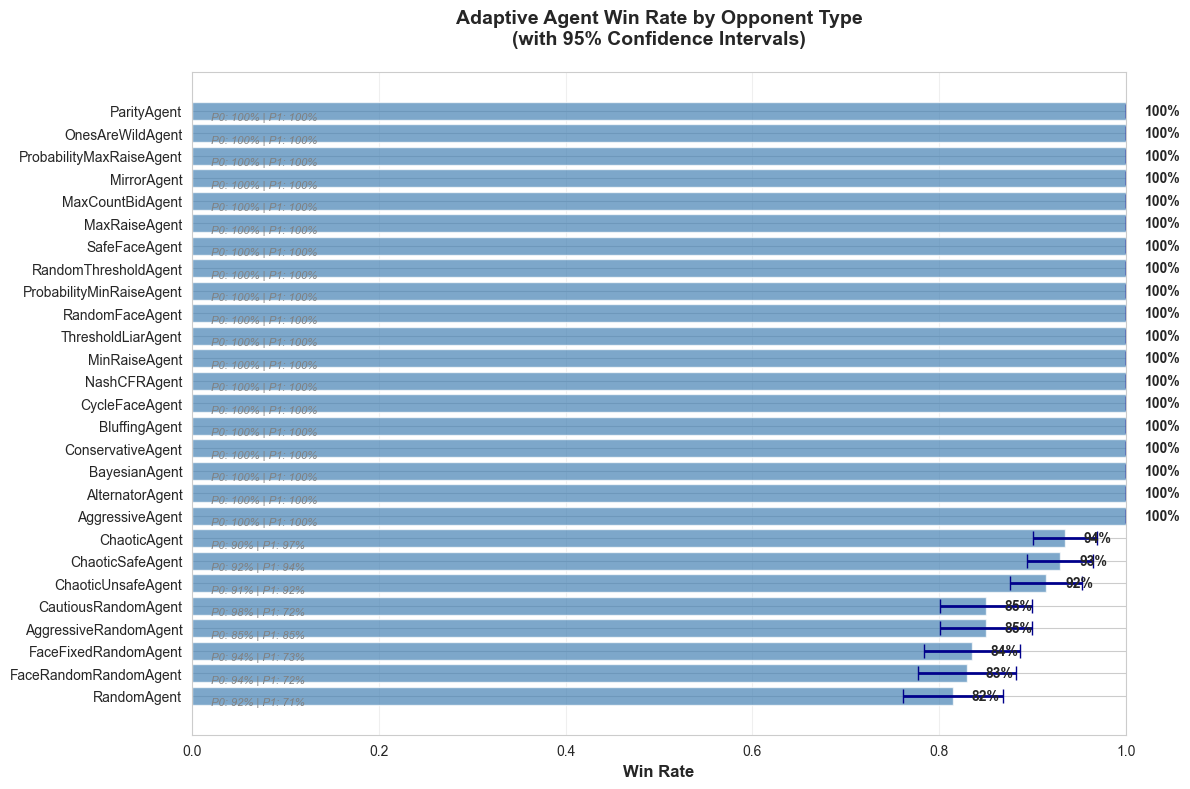

✓ Win rate chart saved as 'adaptive_agent_win_rates.png'


In [50]:
# Sort by win rate for better visualization
df_plot = df_win_rates.sort_values('Win Rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

# Create bar chart with error bars
y_pos = np.arange(len(df_plot))
bars = ax.barh(y_pos, df_plot['Win Rate'].values, 
                xerr=df_plot['CI'].values,
                capsize=5, alpha=0.7, color='steelblue', 
                error_kw={'linewidth': 2, 'ecolor': 'darkblue'})

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['Opponent'].values)
ax.set_xlabel('Win Rate', fontsize=12, fontweight='bold')
ax.set_title('Adaptive Agent Win Rate by Opponent Type\n(with 95% Confidence Intervals)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

# Add percentage labels and player position info
for i, (idx, row) in enumerate(df_plot.iterrows()):
    wr_pct = f"{row['Win Rate']:.0%}"
    p0_pct = f"{row['P0 WR']:.0%}"
    p1_pct = f"{row['P1 WR']:.0%}"
    
    # Win rate label
    ax.text(row['Win Rate'] + 0.02, i, f"{wr_pct}", 
            va='center', fontweight='bold', fontsize=10)
    
    # Player position labels (smaller)
    ax.text(0.02, i - 0.3, f"P0: {p0_pct} | P1: {p1_pct}", 
            va='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig('adaptive_agent_win_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Win rate chart saved as 'adaptive_agent_win_rates.png'")

## 8. Analyze Steps Until Adversary Identification

In [51]:
print("="*60)
print("ADVERSARY IDENTIFICATION SPEED")
print("="*60)

# Overall statistics
steps_data = df_results['steps_to_identification'].values
print(f"\nOverall Statistics:")
print(f"  Mean steps to ID: {np.mean(steps_data):.2f}")
print(f"  Median steps to ID: {np.median(steps_data):.2f}")
print(f"  Std Dev: {np.std(steps_data):.2f}")
print(f"  Min: {np.min(steps_data):.0f}, Max: {np.max(steps_data):.0f}")

# By opponent
print(f"\n" + "="*60)
print("STEPS TO IDENTIFICATION BY OPPONENT")
print("="*60)

id_speed_data = []
for opp in sorted(df_results['opponent'].unique()):
    opp_steps = df_results[df_results['opponent'] == opp]['steps_to_identification'].values
    id_speed_data.append({
        'Opponent': opp,
        'Mean Steps': np.mean(opp_steps),
        'Median Steps': np.median(opp_steps),
        'Std Dev': np.std(opp_steps),
        'Min': np.min(opp_steps),
        'Max': np.max(opp_steps),
    })

df_id_speed = pd.DataFrame(id_speed_data)
df_id_speed = df_id_speed.sort_values('Mean Steps')
print(df_id_speed.to_string(index=False))

ADVERSARY IDENTIFICATION SPEED

Overall Statistics:
  Mean steps to ID: 11.42
  Median steps to ID: 11.00
  Std Dev: 1.96
  Min: 5, Max: 18

STEPS TO IDENTIFICATION BY OPPONENT
                Opponent  Mean Steps  Median Steps  Std Dev  Min  Max
     CautiousRandomAgent       9.970          10.0 1.972080    5   15
           MaxRaiseAgent      10.000          10.0 0.000000   10   10
         RandomFaceAgent      10.065          10.0 0.347527   10   12
   FaceRandomRandomAgent      10.120          10.0 2.048316    5   15
             RandomAgent      10.145          10.0 2.200903    5   16
    FaceFixedRandomAgent      10.225          10.0 2.030856    5   15
   AggressiveRandomAgent      10.295          11.0 2.155916    5   14
          CycleFaceAgent      10.500          10.5 0.500000   10   11
           MinRaiseAgent      10.500          10.5 0.500000   10   11
           SafeFaceAgent      10.500          10.5 0.500000   10   11
           BluffingAgent      10.795          10.0 0.

In [7]:
print("="*80)
print("GENERALIST PPO DIAGNOSTIC")
print("="*80)

# Filter GeneralistPPO games
gen_games = df_results[df_results['opponent'] == 'GeneralistPPO']

if len(gen_games) > 0:
    print(f"\nTotal GeneralistPPO games: {len(gen_games)}")
    print(f"Adaptive won: {gen_games['adaptive_won'].sum()}/{len(gen_games)} ({gen_games['adaptive_won'].mean():.1%})")
    print(f"P0 win rate: {gen_games[gen_games['adaptive_is_player_0']==True]['adaptive_won'].mean():.1%}")
    print(f"P1 win rate: {gen_games[gen_games['adaptive_is_player_0']==False]['adaptive_won'].mean():.1%}")
    
    print(f"\n--- Identification Analysis ---")
    print(f"Correctly identified: {gen_games['identification_correct'].sum()}/{len(gen_games)} ({gen_games['identification_correct'].mean():.1%})")
    print(f"Mean steps to identification: {gen_games['steps_to_identification'].mean():.1f}")
    print(f"Median steps to identification: {gen_games['steps_to_identification'].median():.1f}")
    
    print(f"\n--- What was predicted? ---")
    print(gen_games['predicted_opponent'].value_counts())
    
    # Check if identified games have better win rate
    identified = gen_games[gen_games['identification_correct'] == True]
    not_identified = gen_games[gen_games['identification_correct'] == False]
    
    if len(identified) > 0:
        print(f"\n--- Win Rate When Correctly Identified ---")
        print(f"Correctly identified games: {len(identified)}")
        print(f"Win rate: {identified['adaptive_won'].mean():.1%}")
        print(f"Mean identification step: {identified['steps_to_identification'].mean():.1f}")
    
    if len(not_identified) > 0:
        print(f"\n--- Win Rate When NOT Correctly Identified ---")
        print(f"Misidentified games: {len(not_identified)}")
        print(f"Win rate: {not_identified['adaptive_won'].mean():.1%}")
        print(f"Mean identification step: {not_identified['steps_to_identification'].mean():.1f}")
        print(f"Predicted as: {not_identified['predicted_opponent'].value_counts().to_dict()}")
    
    print(f"\n--- Key Question: Is the specialist being selected? ---")
    if gen_games['identification_correct'].mean() > 0.5:
        print("✓ Classifier IS identifying GeneralistPPO in most games")
        if identified['adaptive_won'].mean() < 0.7:
            print("⚠️  But win rate is still low even when identified!")
            print("   → Possible issues:")
            print("      1. Specialist might not be as strong as training suggests")
            print("      2. Not enough steps to switch before game ends")
            print("      3. Bug in expert selection logic")
    else:
        print("✗ Classifier is NOT identifying GeneralistPPO reliably")
        print("   → Agent is using generalist or wrong specialist")
else:
    print("No GeneralistPPO games found!")

print("\n" + "="*80)

GENERALIST PPO DIAGNOSTIC

Total GeneralistPPO games: 10
Adaptive won: 5/10 (50.0%)
P0 win rate: 100.0%
P1 win rate: 0.0%

--- Identification Analysis ---
Correctly identified: 10/10 (100.0%)
Mean steps to identification: 5.5
Median steps to identification: 5.5

--- What was predicted? ---
predicted_opponent
GeneralistPPO    10
Name: count, dtype: int64

--- Win Rate When Correctly Identified ---
Correctly identified games: 10
Win rate: 50.0%
Mean identification step: 5.5

--- Key Question: Is the specialist being selected? ---
✓ Classifier IS identifying GeneralistPPO in most games
⚠️  But win rate is still low even when identified!
   → Possible issues:
      1. Specialist might not be as strong as training suggests
      2. Not enough steps to switch before game ends
      3. Bug in expert selection logic



## 9. Diagnostic: GeneralistPPO Identification Analysis

In [8]:
import logging

# Add detailed logging to adaptive agent
logging.basicConfig(level=logging.INFO, format='%(message)s')

# Create a test function with detailed tracking
def play_game_with_detailed_logging(
    adaptive_agent: AdaptiveAgent,
    opponent_cls,
    opponent_name: str,
    game_config: GameConfig,
    adaptive_is_player_0: bool = True
):
    """Play a single game with detailed logging of agent selection."""
    
    print(f"\n{'='*80}")
    print(f"STARTING GAME: Adaptive vs {opponent_name}")
    print(f"Adaptive is Player {0 if adaptive_is_player_0 else 1}")
    print(f"{'='*80}\n")
    
    # Setup agents
    opponent = opponent_cls()
    adaptive_agent.reset()
    
    # Wrap opponent to track its actions
    wrapped_opponent = ActionTrackerWrapper(opponent, adaptive_agent=adaptive_agent)
    
    if adaptive_is_player_0:
        agents = [adaptive_agent, wrapped_opponent]
        adaptive_player = 0
    else:
        agents = [wrapped_opponent, adaptive_agent]
        adaptive_player = 1
    
    # Play match with dice elimination
    engine = GameEngine(game_config)
    dice_counts = [game_config.total_dice, game_config.total_dice]
    
    action_count = 0
    adaptive_action_count = 0
    
    while min(dice_counts) > 0:
        # Update dice counts
        for i in range(2):
            engine.state.players[i].num_dice = dice_counts[i]
        engine.start_new_round()
        
        print(f"\n--- Round {engine.state.public.round_index} (Dice: P0={dice_counts[0]}, P1={dice_counts[1]}) ---")
        
        # Play round
        while not engine.is_terminal():
            current_player = engine.state.public.current_player
            view = engine.get_view(current_player)
            
            if current_player == adaptive_player:
                adaptive_action_count += 1
                
                # Show belief state BEFORE action
                beliefs = adaptive_agent.belief_tracker.get_belief_distribution()
                top_3_beliefs = sorted(beliefs.items(), key=lambda x: x[1], reverse=True)[:3]
                print(f"\n  [Adaptive Turn {adaptive_action_count}] Observations: {adaptive_agent.observations_count}")
                print(f"  Top 3 Beliefs: {[(name, f'{prob:.1%}') for name, prob in top_3_beliefs]}")
                
                # Check which agent will be selected
                selected_agent = adaptive_agent._select_agent()
                agent_type = "GENERALIST"
                if adaptive_agent.current_expert and adaptive_agent.current_expert in adaptive_agent.experts:
                    agent_type = f"EXPERT[{adaptive_agent.current_expert}]"
                
                print(f"  → Selected Agent: {agent_type}")
                
                # Now choose action
                action = agents[current_player].choose_action(view)
                print(f"  → Action: {action}")
            else:
                # Opponent turn
                action = agents[current_player].choose_action(view)
                print(f"  [Opponent Turn] Action: {action}")
            
            action_count += 1
            
            try:
                engine.apply_action(current_player, action)
            except Exception as e:
                print(f"  ERROR applying action: {e}")
                break
        
        # Round ended
        if engine.is_terminal():
            round_loser = engine.state.public.loser
            dice_counts[round_loser] -= 1
            print(f"  → Round ended. Player {round_loser} loses a die")
    
    # Determine winner
    winner = 0 if dice_counts[0] > 0 else 1
    adaptive_won = (winner == adaptive_player)
    
    print(f"\n{'='*80}")
    print(f"GAME ENDED: {'ADAPTIVE WINS' if adaptive_won else 'OPPONENT WINS'}")
    print(f"Winner: Player {winner}")
    print(f"Total actions: {action_count} (Adaptive: {adaptive_action_count})")
    print(f"{'='*80}\n")
    
    return adaptive_won

# Run 2 games against GeneralistPPO (one as P0, one as P1)
print("\n" + "="*80)
print("DETAILED LOGGING TEST: 2 Games vs GeneralistPPO")
print("="*80)

test_agent = AdaptiveAgent(device="cpu")
test_opponent = GeneralistPPOAgent

# Game 1: Adaptive as Player 0
print("\n\nGAME 1: Adaptive as Player 0")
result_p0 = play_game_with_detailed_logging(
    test_agent, test_opponent, "GeneralistPPO", game_config, adaptive_is_player_0=True
)

# Game 2: Adaptive as Player 1
print("\n\nGAME 2: Adaptive as Player 1")
result_p1 = play_game_with_detailed_logging(
    test_agent, test_opponent, "GeneralistPPO", game_config, adaptive_is_player_0=False
)

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"P0 Result: {'WIN' if result_p0 else 'LOSS'}")
print(f"P1 Result: {'WIN' if result_p1 else 'LOSS'}")
print("="*80)


DETAILED LOGGING TEST: 2 Games vs GeneralistPPO
  ✓ Loaded expert for BayesianAgent
  ✓ Loaded expert for ConservativeAgent
  ✓ Loaded expert for AggressiveAgent
  ✓ Loaded expert for ProbabilityMinRaiseAgent
  ✓ Loaded expert for ProbabilityMaxRaiseAgent
  ✓ Loaded expert for MinRaiseAgent
  ✓ Loaded expert for MaxRaiseAgent
  ✓ Loaded expert for MirrorAgent
  ✓ Loaded expert for MaxCountBidAgent
  ✓ Loaded expert for RandomFaceAgent
  ✓ Loaded expert for SafeFaceAgent
  ✓ Loaded expert for OnesAreWildAgent
  ✓ Loaded expert for BluffingAgent
  ✓ Loaded expert for ThresholdLiarAgent
  ✓ Loaded expert for ChaoticAgent
  ✓ Loaded expert for ChaoticSafeAgent
  ✓ Loaded expert for ChaoticUnsafeAgent
  ✓ Loaded expert for AlternatorAgent
  ✓ Loaded expert for CycleFaceAgent
  ✓ Loaded expert for ParityAgent
  ✓ Loaded expert for RandomThresholdAgent
  ✓ Loaded expert for NashCFRAgent
  ✓ Loaded expert for RandomAgent
  ✓ Loaded expert for CautiousRandomAgent
  ✓ Loaded expert for Aggressi